# Importing Required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pyodbc

conn = pyodbc.connect(
    r"DRIVER={ODBC Driver 17 for SQL Server};"
    r"SERVER=MIKASA\SQLEXPRESS;"
    r"DATABASE=Bank_Analytics;"
    r"Trusted_Connection=yes;"
)

print("Connected Successfully!")

Connected Successfully!


In [3]:
cursor = conn.cursor()
cursor.execute("SELECT @@VERSION")
print(cursor.fetchone()[0])

Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64) 
	Oct  8 2022 05:58:25 
	Copyright (C) 2022 Microsoft Corporation
	Express Edition (64-bit) on Windows 10 Home Single Language 10.0 <X64> (Build 26200: )



# Connecting SQL Database in python

In [4]:
import pandas as pd

account = pd.read_sql("SELECT * FROM Account", conn)
client = pd.read_sql("SELECT * FROM Client", conn)
district = pd.read_sql("SELECT * FROM District", conn)
disp = pd.read_sql("SELECT * FROM Disp", conn)      # Use Disposition if that's your table name
card = pd.read_sql("SELECT * FROM Card", conn)
loan = pd.read_sql("SELECT * FROM Loan", conn)
orders = pd.read_sql("SELECT * FROM [Order]", conn)
transaction = pd.read_sql("SELECT * FROM Transaction_Merged", conn) 

# Data Preposing before Analysis

In [69]:
# DECODE birth_number — run this cell
client['birth_number'] = client['birth_number'].astype(str).str.zfill(6)

client['yr_raw']      = client['birth_number'].str[0:2].astype(int)
client['month_raw']   = client['birth_number'].str[2:4].astype(int)
client['day']         = client['birth_number'].str[4:6].astype(int)

client['gender']      = client['month_raw'].apply(lambda m: 'F' if m > 50 else 'M')
client['birth_month'] = client['month_raw'].apply(lambda m: m - 50 if m > 50 else m)
client['birth_year']  = client['yr_raw'] + 1900
client['age']         = 1998 - client['birth_year']
client['age_group']   = pd.cut(client['age'],
                          bins=[0, 25, 35, 45, 55, 65, 100],
                          labels=['<25','25-35','35-45','45-55','55-65','65+'])

# Verify — run this to confirm it worked
print(client[['client_id','birth_number','gender','birth_year','birth_month','day','age']].head(10))

   client_id birth_number gender  birth_year  birth_month  day  age
0          1       706213      F        1970           12   13   28
1          2       450204      M        1945            2    4   53
2          3       406009      F        1940           10    9   58
3          4       561201      M        1956           12    1   42
4          5       605703      F        1960            7    3   38
5          6       190922      M        1919            9   22   79
6          7       290125      M        1929            1   25   69
7          8       385221      F        1938            2   21   60
8          9       351016      M        1935           10   16   63
9         10       430501      M        1943            5    1   55


In [70]:
loan['date'] = pd.to_datetime(loan['date'])
transaction['Date'] = pd.to_datetime(transaction['Date'])
transaction['year'] = transaction['Date'].dt.year
transaction['month'] = transaction['Date'].dt.month
transaction['type_lbl']= transaction['Type'].map({'PRIJEM':'Credit','VYDAJ':'Debit'})
loan['year']           = loan['date'].dt.year
loan['is_default']     = (loan['status'] == 'D').astype(int)
status_map = {'A':'Completed OK','B':'Completed Issue','C':'Active','D':'Default'}
loan['status_lbl']     = loan['status'].map(status_map)
card['issued_date'] = pd.to_datetime(card['issued_date'])
card['card_year'] = card['issued_date'].dt.year

In [7]:
district.rename(columns={'A1':'district_id','A2':'name','A3':'region',
                          'A4':'population','A11':'avg_salary',
                          'A12':'unemp_95','A13':'unemp_96',
                          'A15':'crimes_95','A16':'crimes_96'}, inplace=True)
for c in ['population','avg_salary','unemp_96']:
    district[c] = pd.to_numeric(district[c], errors='coerce')

In [8]:
# Master join (OWNER disposition only)
owners = disp[disp['type'].str.upper()=='OWNER'][['account_id','client_id']]
 
acc_cli = (account
    .merge(owners, on='account_id', how='left')
    .merge(client[['client_id','gender','age','age_group']], on='client_id', how='left')
    .merge(district[['district_id','name','region','population',
                      'avg_salary','unemp_96']], on='district_id', how='left'))
 
loan_cli = (loan
    .merge(owners, on='account_id', how='left')
    .merge(client[['client_id','gender','age','age_group']], on='client_id', how='left')
    .merge(account[['account_id','district_id']], on='account_id', how='left')
    .merge(district[['district_id','name','avg_salary','unemp_96']],
           on='district_id', how='left'))
 
print("✅ Data prep done. Ready for analysis.")

✅ Data prep done. Ready for analysis.


In [9]:
account['date'] = pd.to_datetime(account['date'])

# Descriptive Analysis

### Customer Demographics

In [10]:
print(f"Total Clients     : {client['client_id'].nunique():,}")
print(f"Avg Age           : {client['age'].mean():.1f}")
print(f"Female %          : {(client['gender']=='F').mean()*100:.1f}%")
print(f"Districts covered : {client['district_id'].nunique()}")

Total Clients     : 5,369
Avg Age           : 44.8
Female %          : 49.3%
Districts covered : 77


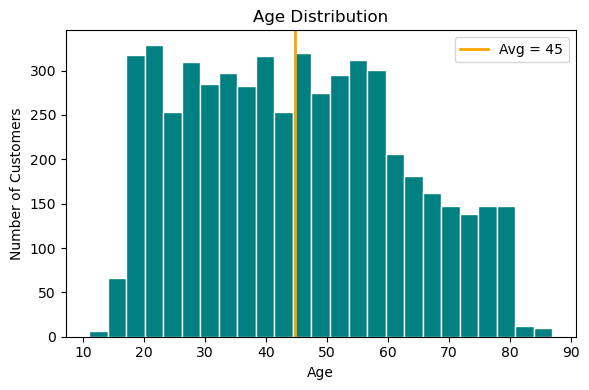

In [11]:
# Age histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(client['age'], bins=25, color='teal', edgecolor='white')

plt.axvline(
    client['age'].mean(),
    color='orange',
    linewidth=2,
    label=f"Avg = {client['age'].mean():.0f}"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

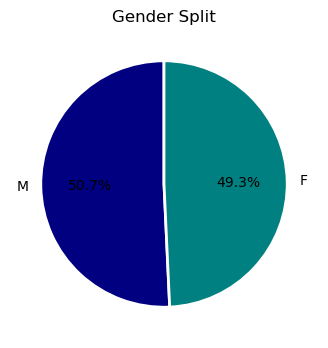

In [12]:
# Gender pie
g = client['gender'].value_counts()

plt.figure(figsize=(4, 4))

plt.pie(
    g,
    labels=g.index,
    colors=['navy', 'teal'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)

plt.title("Gender Split")
plt.show()

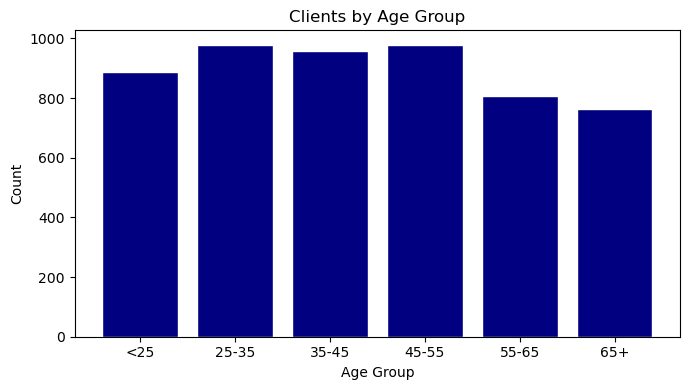

In [13]:
# Age group bar by gender
plt.figure(figsize=(7, 4))
age_grp = client['age_group'].value_counts().sort_index()
plt.bar(age_grp.index.astype(str), age_grp.values, color='NAVY', edgecolor='white')
plt.title('Clients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

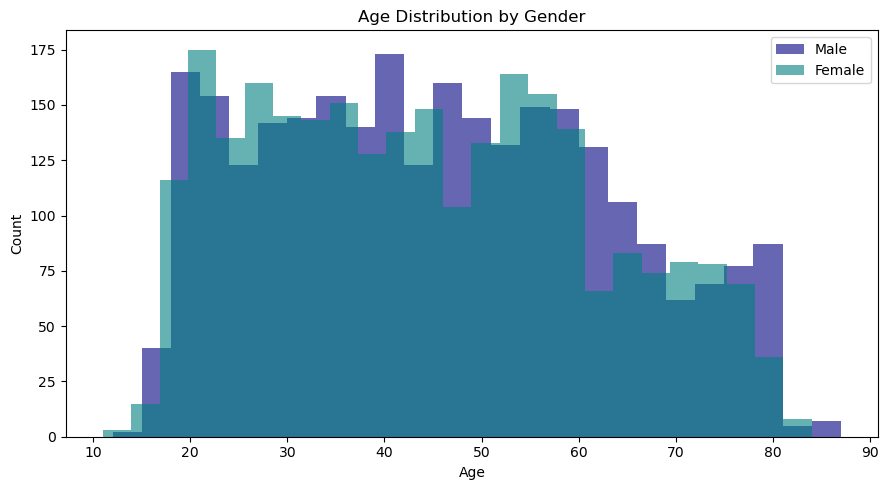

In [14]:
plt.figure(figsize=(9, 5))
plt.hist(client[client['gender'] == 'M']['age'], bins=25,
         alpha=0.6, color='NAVY', label='Male')
plt.hist(client[client['gender'] == 'F']['age'], bins=25,
         alpha=0.6, color='TEAL', label='Female')
plt.title('Age Distribution by Gender')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### ACCOUNT ANALYSIS

In [15]:
print(f"Total Accounts   : {account['account_id'].nunique():,}")
print(f"Account Types    :\n{account['Account_type'].value_counts()}")
print(f"Frequency dist   :\n{account['frequency'].value_counts()}")

Total Accounts   : 4,500
Account Types    :
Account_type
Savings account    1533
NRI account        1522
Salary account     1445
Name: count, dtype: int64
Frequency dist   :
frequency
POPLATEK MESICNE      4167
POPLATEK TYDNE         240
POPLATEK PO OBRATU      93
Name: count, dtype: int64


In [16]:
account['acc_year'] = account['date'].dt.year

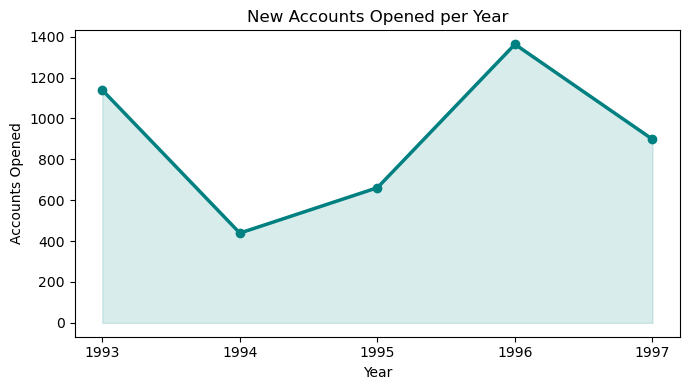

In [17]:
# Chart 1: New accounts per year
plt.figure(figsize=(7, 4))
yr = account.groupby('acc_year')['account_id'].count()
plt.plot(yr.index, yr.values, color='TEAL', marker='o', linewidth=2.5)
plt.fill_between(yr.index, yr.values, alpha=0.15, color='TEAL')
plt.title('New Accounts Opened per Year')
plt.xlabel('Year')
plt.ylabel('Accounts Opened')
plt.xticks(yr.index)
plt.tight_layout()
plt.show()

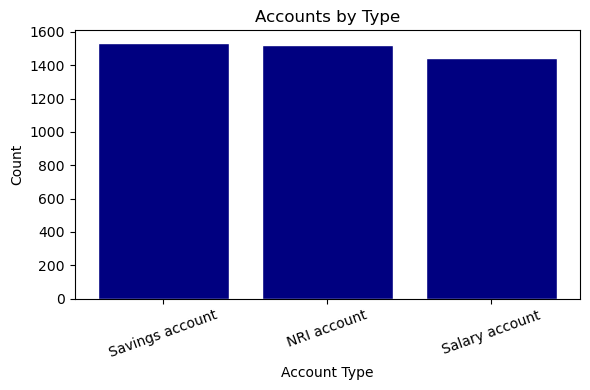

In [18]:
# Chart 2: Account type bar
plt.figure(figsize=(6, 4))
at = account['Account_type'].value_counts()
plt.bar(at.index, at.values, color='NAVY', edgecolor='white')
plt.title('Accounts by Type')
plt.xlabel('Account Type')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

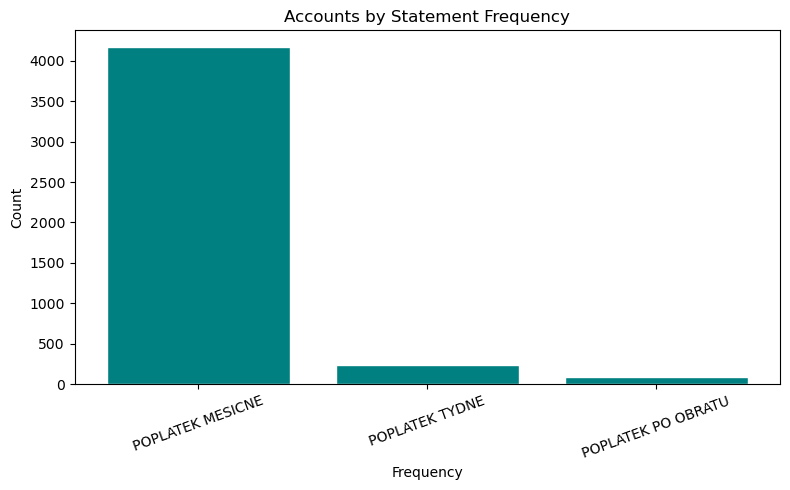

In [19]:
# Chart 3: Account frequency distribution
plt.figure(figsize=(8, 5))
fr = account['frequency'].value_counts()
plt.bar(fr.index, fr.values, color='TEAL', edgecolor='white')
plt.title('Accounts by Statement Frequency')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Transaction Overview

In [20]:
total_credit = transaction.loc[
    transaction['Type'] == 'Credit', 'amount'
].sum()

total_debit = transaction.loc[
    transaction['Type'] == 'Withdrawal', 'amount'
].sum()

avg_txn = transaction['amount'].mean()

print(f"Total Transactions : {len(transaction):,}")
print(f"Total Credit (CZK) : {total_credit:,.0f}")
print(f"Total Debit (CZK)  : {total_debit:,.0f}")
print(f"Avg Txn Amount     : {avg_txn:,.2f}")
print(f"Credit:Debit Ratio : {total_credit / total_debit:.2f}")

Total Transactions : 1,048,575
Total Credit (CZK) : 3,216,335,973
Total Debit (CZK)  : 3,014,457,408
Avg Txn Amount     : 5,942.15
Credit:Debit Ratio : 1.07


In [21]:
print(transaction['Type'].value_counts())
print(transaction['type_lbl'].value_counts(dropna=False))

transaction['type_lbl'] = transaction['Type'].replace({
    'Credit': 'Credit',
    'Withdrawal': 'Debit'
})

Type
Withdrawal    648366
Credit        400209
Name: count, dtype: int64
type_lbl
NaN    1048575
Name: count, dtype: int64


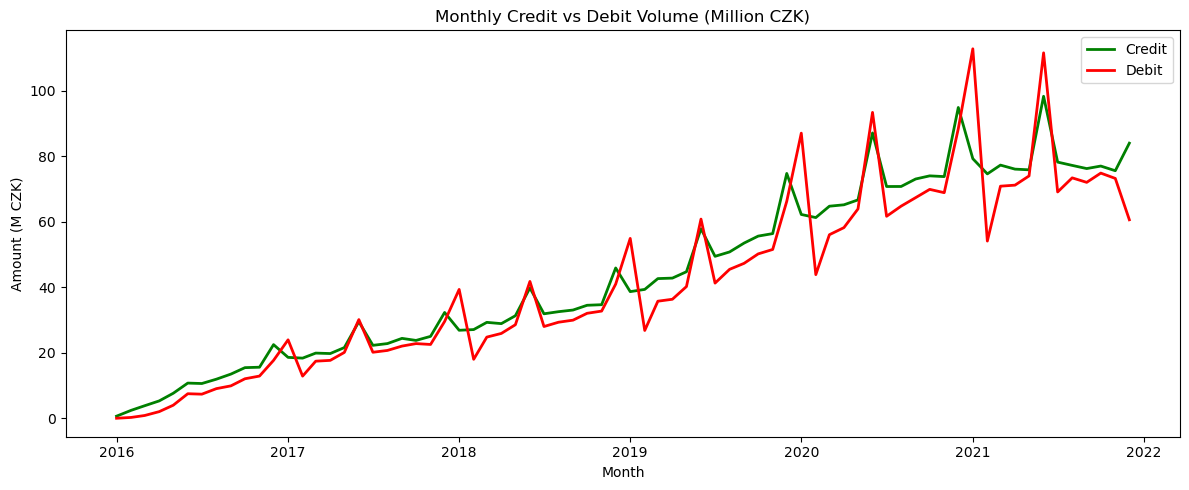

In [22]:
# Chart 1: Monthly credit vs debit trend
monthly = (transaction.groupby(['year', 'month', 'type_lbl'])['amount']
           .sum().reset_index())
monthly['period'] = pd.to_datetime(
    monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2))
 
plt.figure(figsize=(12, 5))
for t, c in [('Credit', 'GREEN'), ('Debit', 'RED')]:
    sub = monthly[monthly['type_lbl'] == t].sort_values('period')
    plt.plot(sub['period'], sub['amount'] / 1e6, label=t, color=c, linewidth=2)
plt.title('Monthly Credit vs Debit Volume (Million CZK)')
plt.xlabel('Month')
plt.ylabel('Amount (M CZK)')
plt.legend()
plt.tight_layout()
plt.show()

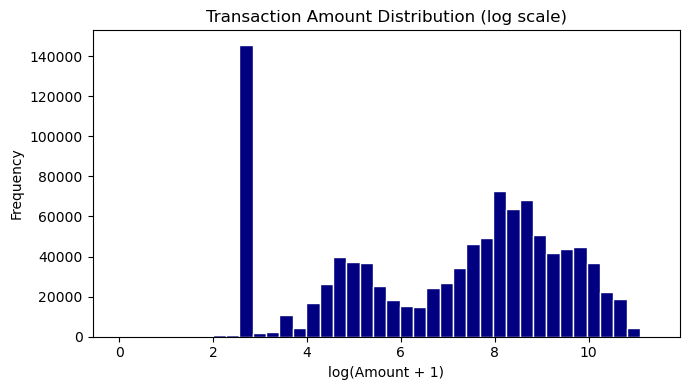

In [23]:
# Chart 2: Transaction amount distribution
plt.figure(figsize=(7, 4))
plt.hist(np.log1p(transaction['amount']), bins=40, color='NAVY', edgecolor='white')
plt.title('Transaction Amount Distribution (log scale)')
plt.xlabel('log(Amount + 1)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

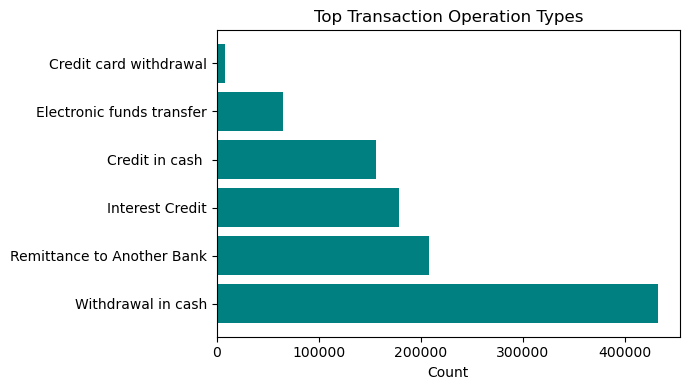

In [24]:
# Chart 3: Top operation types
plt.figure(figsize=(7, 4))
op = transaction['operation'].value_counts().head(7)
plt.barh(op.index, op.values, color='TEAL')
plt.title('Top Transaction Operation Types')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

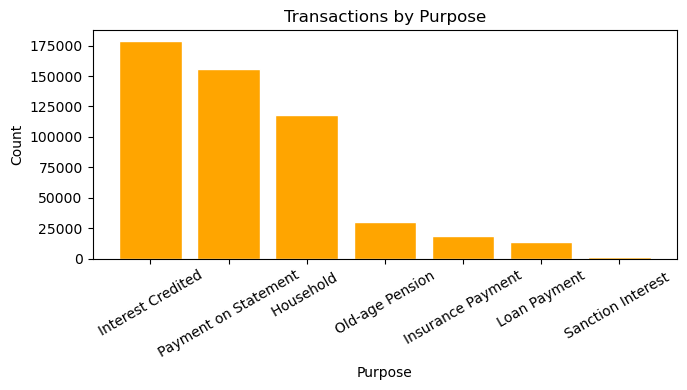

In [25]:
# Chart 4: Purpose / k_symbol
plt.figure(figsize=(7, 4))
pu = transaction['Purpose'].value_counts().head(7)
plt.bar(pu.index, pu.values, color='ORANGE', edgecolor='white')
plt.title('Transactions by Purpose')
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [26]:
# Yearly summary
yearly_txn = transaction.groupby('year').agg(
    count  = ('trans_id', 'count'),
    credit = ('amount',   lambda x: x[transaction.loc[x.index, 'type_lbl'] == 'Credit'].sum()),
    debit  = ('amount',   lambda x: x[transaction.loc[x.index, 'type_lbl'] == 'Debit'].sum()),
    avg    = ('amount',   'mean')
).reset_index()
print("\nYearly Summary:")
print(yearly_txn.round(0).to_string(index=False))


Yearly Summary:
 year  count    credit     debit    avg
 2016  28205 120442617  83867370 7244.0
 2017  91628 278536213 260260433 5880.0
 2018 133022 396068569 371670628 5772.0
 2019 196779 606772930 557091319 5915.0
 2020 284409 864695012 823652878 5936.0
 2021 314532 949820632 917914780 5938.0


## Loan Overview

In [27]:
print("\n--- A4. LOAN OVERVIEW ---")
print(f"Total Loans         : {len(loan):,}")
print(f"Total Exposure (CZK): {loan['amount'].sum():,.0f}")
print(f"Default Rate        : {loan['is_default'].mean() * 100:.2f}%")
print(f"Avg Loan Amount     : {loan['amount'].mean():,.0f}")
print(f"Avg Duration(months): {loan['duration'].mean():.1f}")


--- A4. LOAN OVERVIEW ---
Total Loans         : 682
Total Exposure (CZK): 103,261,740
Default Rate        : 6.60%
Avg Loan Amount     : 151,410
Avg Duration(months): 36.5


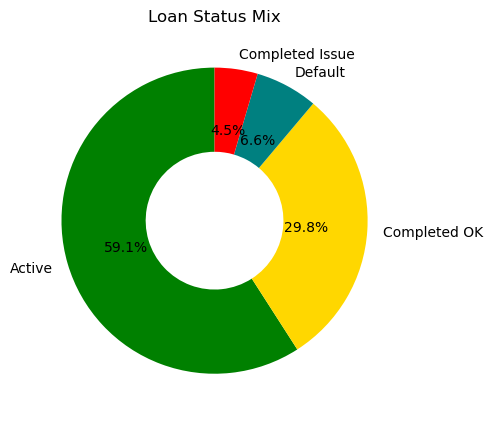

In [28]:
# Chart 1: Loan status donut
plt.figure(figsize=(5, 5))
sc = loan['status_lbl'].value_counts()
plt.pie(sc,
        labels=sc.index,
        colors=['GREEN', 'GOLD', 'TEAL', 'RED'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.55})
plt.title('Loan Status Mix')
plt.tight_layout()
plt.show()

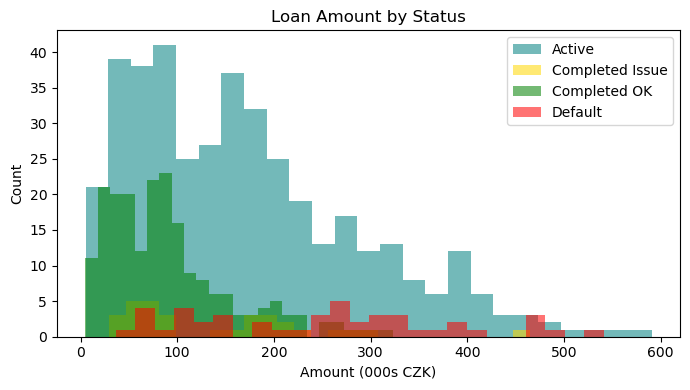

In [29]:
# Chart 2: Loan amount histogram by status
plt.figure(figsize=(7, 4))
colors_s = {'Completed OK': 'GREEN', 'Completed Issue': 'GOLD', 'Active': 'TEAL', 'Default': 'RED'}
for s, grp in loan.groupby('status_lbl'):
    plt.hist(grp['amount'] / 1000, bins=25, alpha=0.55,
             color=colors_s.get(s, 'gray'), label=s)
plt.title('Loan Amount by Status')
plt.xlabel('Amount (000s CZK)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

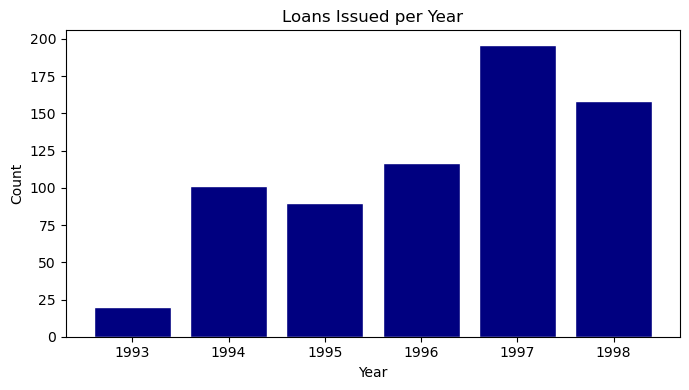

In [30]:
# Chart 3: Loans per year
plt.figure(figsize=(7, 4))
ly = loan.groupby('year')['loan_id'].count()
plt.bar(ly.index, ly.values, color='NAVY', edgecolor='white')
plt.title('Loans Issued per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(ly.index)
plt.tight_layout()
plt.show()

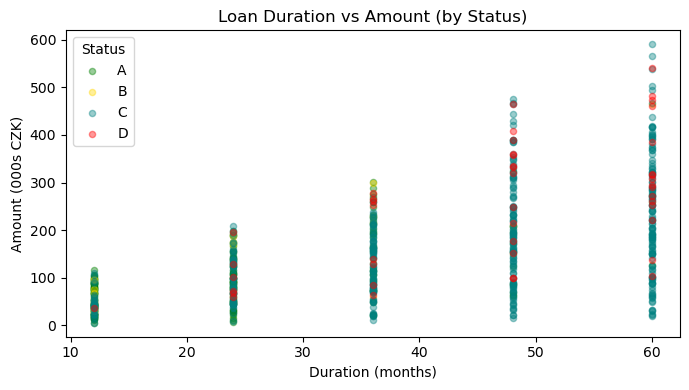

In [31]:
# Chart 4: Duration vs Amount scatter
plt.figure(figsize=(7, 4))
for status, grp in loan.groupby('status'):
    c = {'A': 'GREEN', 'B': 'GOLD', 'C': 'TEAL', 'D': 'RED'}.get(status, 'gray')
    plt.scatter(grp['duration'], grp['amount'] / 1000,
                alpha=0.4, s=20, color=c, label=status)
plt.title('Loan Duration vs Amount (by Status)')
plt.xlabel('Duration (months)')
plt.ylabel('Amount (000s CZK)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

## Card & Product Adaption

In [32]:
total_cards  = len(card)
total_accs   = account['account_id'].nunique()
penetration  = total_cards / total_accs * 100
print(f"Total Cards Issued   : {total_cards:,}")
print(f"Card Penetration Rate: {penetration:.1f}%")
print(card['type'].value_counts())
 
date_col = 'issued_date' if 'issued_date' in card.columns else 'issued'
card['card_year'] = pd.to_datetime(
    card[date_col].astype(str), format='%y%m%d', errors='coerce').dt.year

Total Cards Issued   : 892
Card Penetration Rate: 19.8%
type
classic    659
junior     145
gold        88
Name: count, dtype: int64


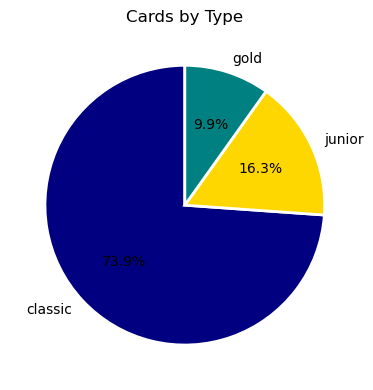

In [33]:
# Chart 1: Card type pie
plt.figure(figsize=(5, 4))
ct = card['type'].str.lower().value_counts()
plt.pie(ct, labels=ct.index,
        colors=['NAVY', 'GOLD', 'TEAL'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Cards by Type')
plt.tight_layout()
plt.show()

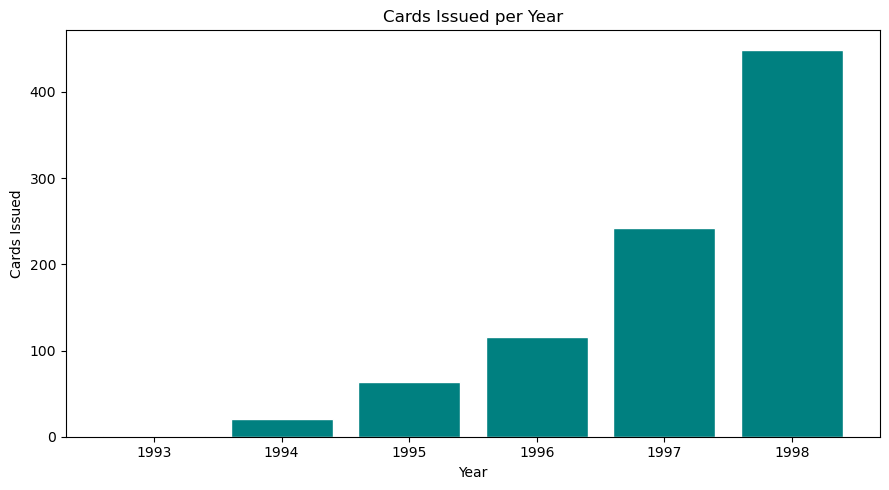

In [71]:
# Chart 2: Card issuance per year
plt.figure(figsize=(9, 5))
cy = card.groupby('card_year')['card_id'].count()
plt.bar(cy.index, cy.values, color='TEAL', edgecolor='white')
plt.title('Cards Issued per Year')
plt.xlabel('Year')
plt.ylabel('Cards Issued')
plt.tight_layout()
plt.show()

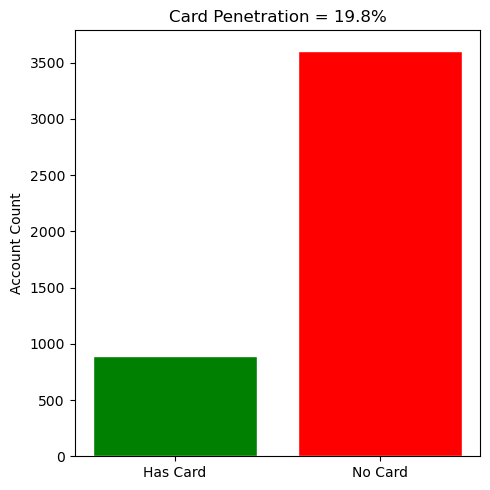

In [35]:
# Chart 3: Penetration bar
plt.figure(figsize=(5, 5))
plt.bar(['Has Card', 'No Card'],
        [total_cards, total_accs - total_cards],
        color=['GREEN', 'RED'], edgecolor='white')
plt.title(f'Card Penetration = {penetration:.1f}%')
plt.ylabel('Account Count')
plt.tight_layout()
plt.show()

## Regional/ District Analysis

In [72]:
acc_district = (account.groupby('district_id')['account_id']
                .count().reset_index(name='acc_count')
                .merge(district[['district_id', 'name', 'region',
                                  'population', 'avg_salary', 'unemp_96']],
                       on='district_id', how='left'))
acc_district['acc_per_1000'] = (
    acc_district['acc_count'] / acc_district['population'] * 1000)

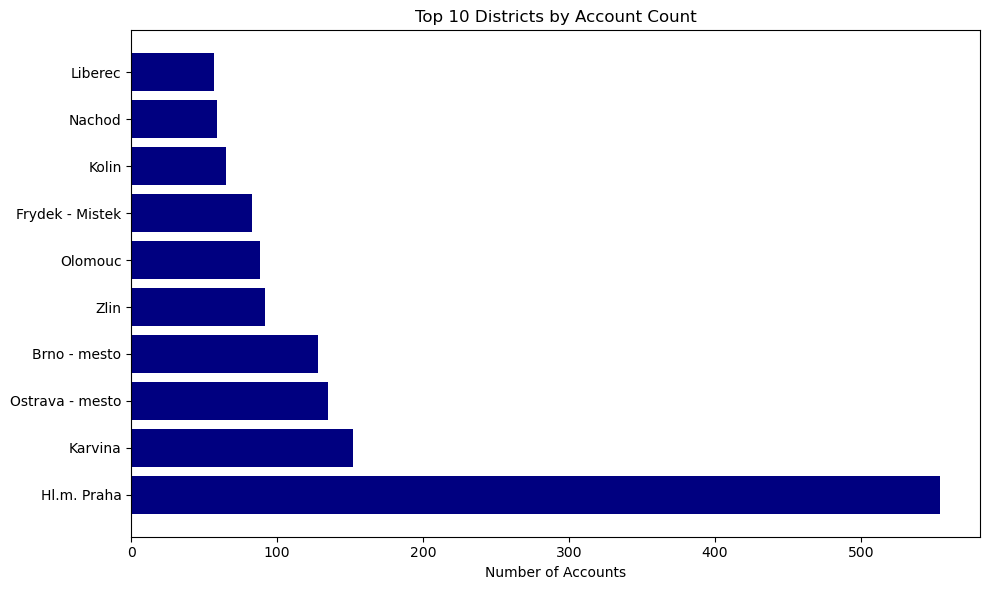

In [38]:
plt.figure(figsize=(10, 6))
top10 = acc_district.nlargest(10, 'acc_count')
plt.barh(top10['name'], top10['acc_count'], color='NAVY')
plt.title('Top 10 Districts by Account Count')
plt.xlabel('Number of Accounts')
plt.tight_layout()
plt.show()

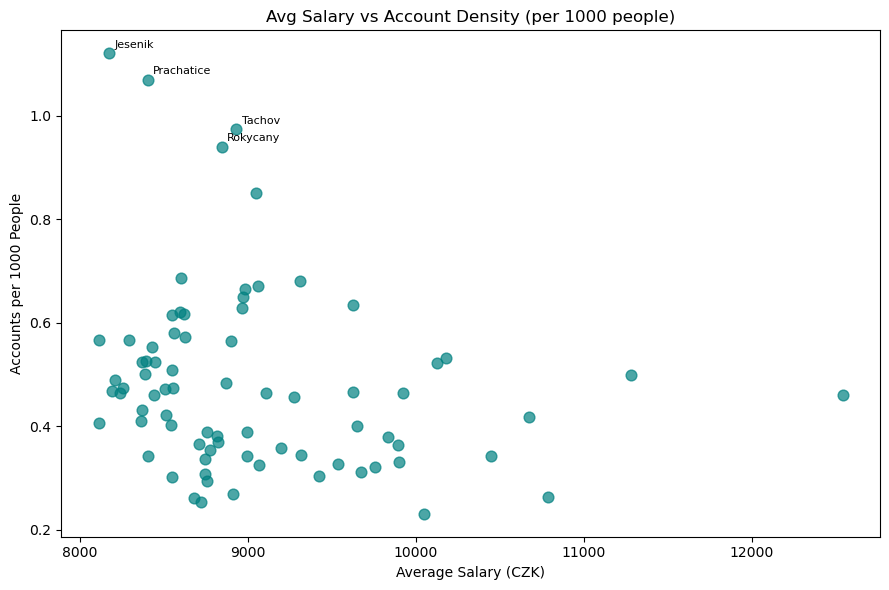

In [39]:
# Chart 2: Salary vs account density scatter
plt.figure(figsize=(9, 6))
plt.scatter(acc_district['avg_salary'], acc_district['acc_per_1000'],
            color='TEAL', alpha=0.7, s=60)
plt.title('Avg Salary vs Account Density (per 1000 people)')
plt.xlabel('Average Salary (CZK)')
plt.ylabel('Accounts per 1000 People')
for _, r in acc_district.nlargest(4, 'acc_per_1000').iterrows():
    plt.annotate(r['name'], (r['avg_salary'], r['acc_per_1000']),
                 fontsize=8, xytext=(4, 4), textcoords='offset points')
plt.tight_layout()
plt.show()

# Diagnostic Analysis

## HIGH DEBIT ACCOUNT RATIO

In [40]:
txn_by_acc = transaction.groupby(['account_id', 'type_lbl'])['amount'].sum().unstack(fill_value=0)
if 'Credit' not in txn_by_acc.columns: txn_by_acc['Credit'] = 0
if 'Debit'  not in txn_by_acc.columns: txn_by_acc['Debit']  = 0
txn_by_acc['debit_ratio']   = txn_by_acc['Debit'] / (txn_by_acc['Credit'] + txn_by_acc['Debit'] + 1)
txn_by_acc['is_high_debit'] = (txn_by_acc['debit_ratio'] > 0.7).astype(int)
txn_by_acc = txn_by_acc.reset_index()

print(f"High-Debit Account Ratio (KPI): {txn_by_acc['is_high_debit'].mean() * 100:.1f}%")

High-Debit Account Ratio (KPI): 0.0%


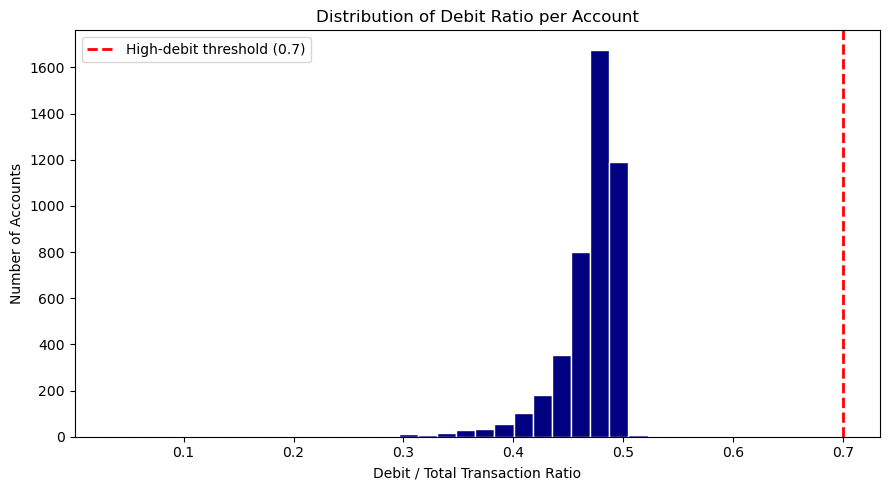

In [41]:
# Chart 1: Debit ratio distribution
plt.figure(figsize=(9, 5))
plt.hist(txn_by_acc['debit_ratio'], bins=30, color='NAVY', edgecolor='white')
plt.axvline(0.7, color='RED', linestyle='--', linewidth=2, label='High-debit threshold (0.7)')
plt.title('Distribution of Debit Ratio per Account')
plt.xlabel('Debit / Total Transaction Ratio')
plt.ylabel('Number of Accounts')
plt.legend()
plt.tight_layout()
plt.show()

## LOAN DEFAULT FACTORS

In [42]:
default_rate = loan_cli['is_default'].mean() * 100
print(f"Overall Default Rate (KPI): {default_rate:.2f}%")
 
defaulters     = loan_cli[loan_cli['is_default'] == 1]
non_defaulters = loan_cli[loan_cli['is_default'] == 0]

Overall Default Rate (KPI): 6.60%


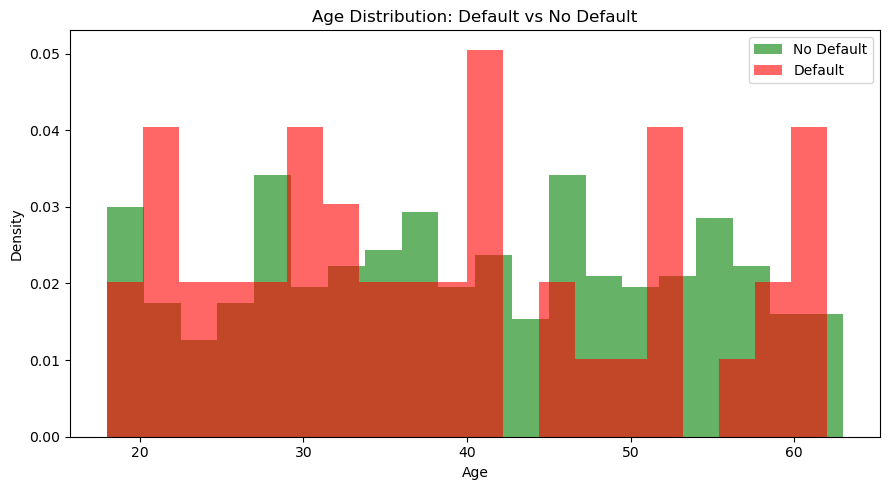

In [43]:
# Chart 1: Age — default vs non-default
plt.figure(figsize=(9, 5))
plt.hist(non_defaulters['age'].dropna(), bins=20,
         alpha=0.6, color='GREEN', label='No Default', density=True)
plt.hist(defaulters['age'].dropna(), bins=20,
         alpha=0.6, color='RED', label='Default', density=True)
plt.title('Age Distribution: Default vs No Default')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

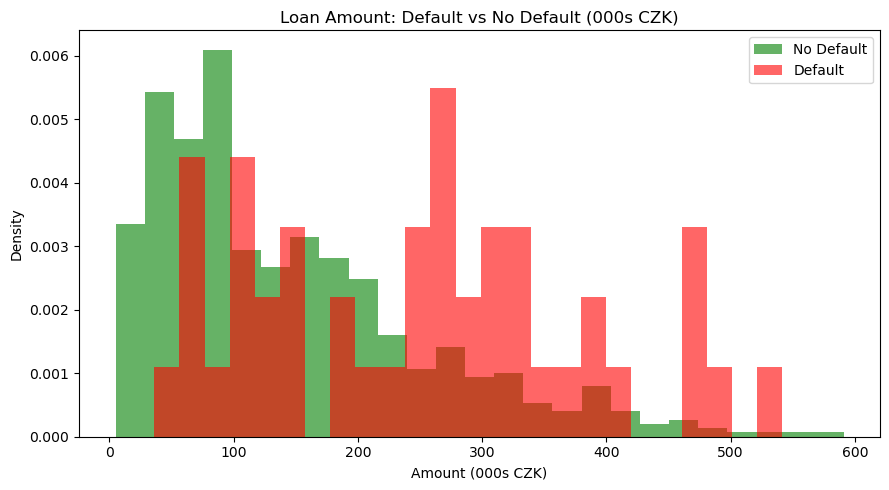

In [44]:
# Chart 2: Loan amount — default vs non-default
plt.figure(figsize=(9, 5))
plt.hist(non_defaulters['amount'].dropna() / 1000, bins=25,
         alpha=0.6, color='GREEN', label='No Default', density=True)
plt.hist(defaulters['amount'].dropna() / 1000, bins=25,
         alpha=0.6, color='RED', label='Default', density=True)
plt.title('Loan Amount: Default vs No Default (000s CZK)')
plt.xlabel('Amount (000s CZK)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

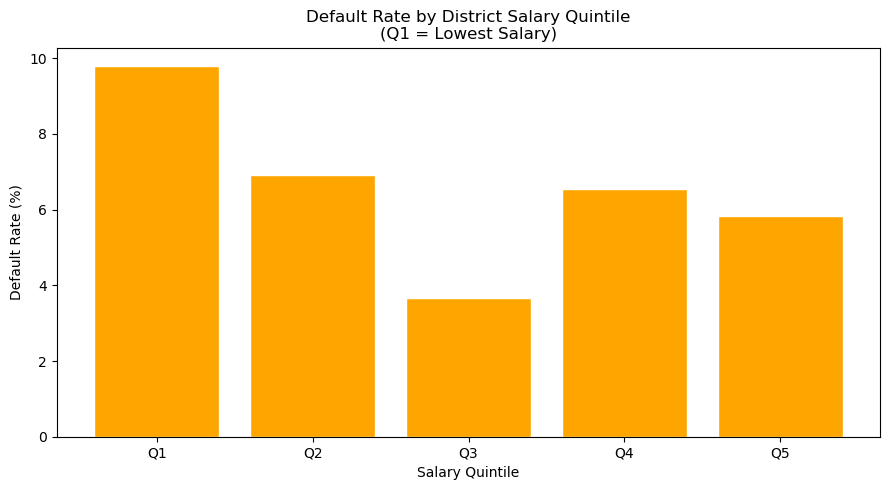

In [45]:
# Chart 3: Default rate by district salary quintile
if 'avg_salary' in loan_cli.columns:
    sal_df   = loan_cli.dropna(subset=['avg_salary', 'is_default'])
    sal_bins = pd.qcut(sal_df['avg_salary'], q=5, duplicates='drop')
    dr_sal   = sal_df.groupby(sal_bins)['is_default'].mean() * 100
 
    plt.figure(figsize=(9, 5))
    plt.bar(range(len(dr_sal)), dr_sal.values, color='ORANGE', edgecolor='white')
    plt.xticks(range(len(dr_sal)), [f'Q{i+1}' for i in range(len(dr_sal))])
    plt.title('Default Rate by District Salary Quintile\n(Q1 = Lowest Salary)')
    plt.xlabel('Salary Quintile')
    plt.ylabel('Default Rate (%)')
    plt.tight_layout()
    plt.show()

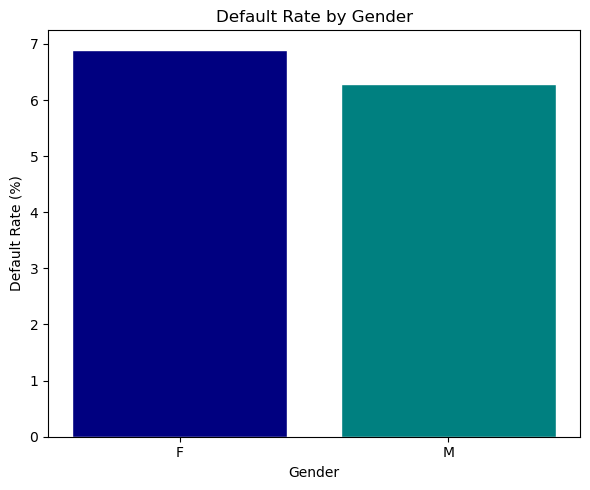

In [46]:
# Chart 4: Default rate by gender
if 'gender' in loan_cli.columns:
    dr_gen = loan_cli.groupby('gender')['is_default'].mean() * 100
    plt.figure(figsize=(6, 5))
    plt.bar(dr_gen.index, dr_gen.values, color=['NAVY', 'TEAL'], edgecolor='white')
    plt.title('Default Rate by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Default Rate (%)')
    plt.tight_layout()
    plt.show()

In [47]:
# Comparison table
compare_cols = [c for c in ['age', 'amount', 'duration', 'avg_salary'] if c in loan_cli.columns]
comparison = loan_cli.groupby('is_default')[compare_cols].mean()
comparison.index = ['No Default', 'Default']
print("\nDefaulter vs Non-Defaulter Averages:")
print(comparison.round(1).T)


Defaulter vs Non-Defaulter Averages:
            No Default   Default
age               40.0      38.5
amount        144496.0  249284.5
duration          35.8      46.1
avg_salary      9514.9    9333.9


## DISTRICT ACCOUNT PENETRATION

In [48]:
pen_df = acc_district.copy()
pen_df['acc_per_1000'] = pen_df['acc_count'] / pen_df['population'] * 1000
print(f"Avg Account Penetration (KPI): {pen_df['acc_per_1000'].mean():.2f} per 1000 people")

Avg Account Penetration (KPI): 0.48 per 1000 people


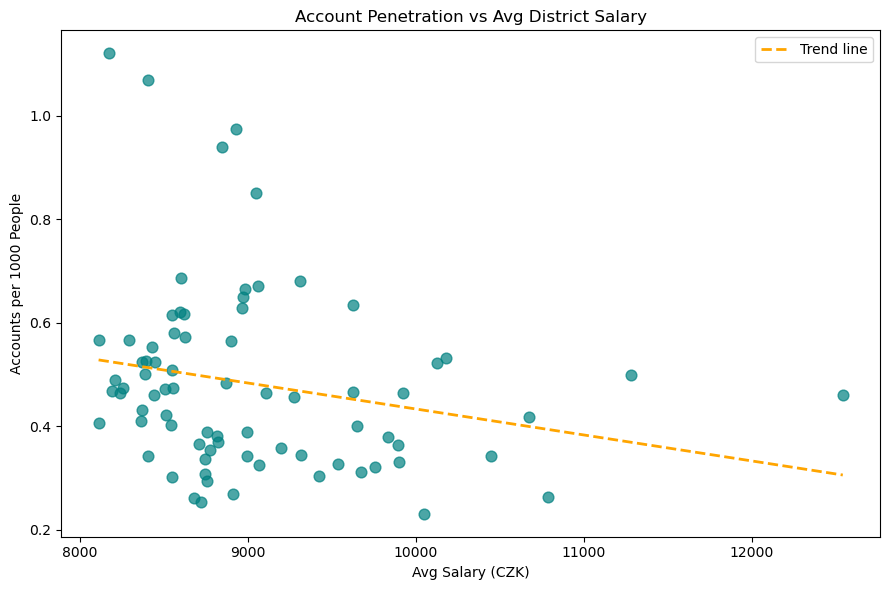

In [49]:
# Chart 1: Penetration vs salary
plt.figure(figsize=(9, 6))
plt.scatter(pen_df['avg_salary'], pen_df['acc_per_1000'],
            color='TEAL', alpha=0.7, s=60)
m, b = np.polyfit(pen_df['avg_salary'].dropna(), pen_df['acc_per_1000'].dropna(), 1)
x_line = np.linspace(pen_df['avg_salary'].min(), pen_df['avg_salary'].max(), 100)
plt.plot(x_line, m * x_line + b, color='ORANGE', linewidth=2,
         linestyle='--', label='Trend line')
plt.title('Account Penetration vs Avg District Salary')
plt.xlabel('Avg Salary (CZK)')
plt.ylabel('Accounts per 1000 People')
plt.legend()
plt.tight_layout()
plt.show()

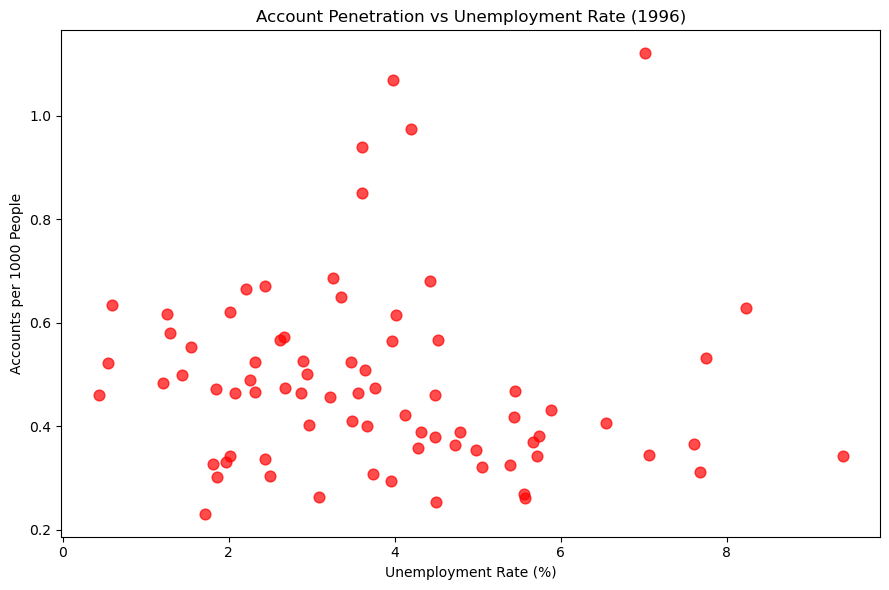

In [50]:
# Chart 2: Penetration vs unemployment
plt.figure(figsize=(9, 6))
plt.scatter(pen_df['unemp_96'], pen_df['acc_per_1000'],
            color='RED', alpha=0.7, s=60)
plt.title('Account Penetration vs Unemployment Rate (1996)')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Accounts per 1000 People')
plt.tight_layout()
plt.show()

In [51]:
# Bottom 10 low-penetration districts
print("\nLowest Penetration Districts:")
print(pen_df.nsmallest(10, 'acc_per_1000')
      [['name', 'region', 'acc_count', 'acc_per_1000', 'avg_salary', 'unemp_96']]
      .round(2).to_string(index=False))


Lowest Penetration Districts:
            name        region  acc_count  acc_per_1000  avg_salary  unemp_96
Ceske Budejovice south Bohemia         41          0.23       10045      1.71
         Hodonin south Moravia         41          0.25        8720      4.50
      Novy Jicin north Moravia         42          0.26        8678      5.57
   Plzen - mesto  west Bohemia         45          0.26       10787      3.09
          Vsetin north Moravia         40          0.27        8909      5.56
         Jihlava south Moravia         32          0.29        8757      3.95
Uherske Hradiste south Moravia         44          0.30        8544      1.86
  Hradec Kralove  east Bohemia         49          0.30        9425      2.50
           Opava north Moravia         56          0.31        8746      3.74
        Chomutov north Bohemia         39          0.31        9675      7.68


## CARD ADOPTION DRIVERS

In [52]:
card_acc_ids     = set(disp.merge(card, on='disp_id')['account_id'])
acc_cli['has_card'] = acc_cli['account_id'].isin(card_acc_ids).astype(int)
print(f"Card Adoption Rate (KPI): {acc_cli['has_card'].mean() * 100:.1f}%")
 
txn_acc = transaction.groupby('account_id').agg(
    txn_count = ('trans_id', 'count'),
    avg_txn   = ('amount',   'mean'),
    avg_bal   = ('balance',  'mean')).reset_index()
acc_cli2 = acc_cli.merge(txn_acc, on='account_id', how='left')

Card Adoption Rate (KPI): 19.8%


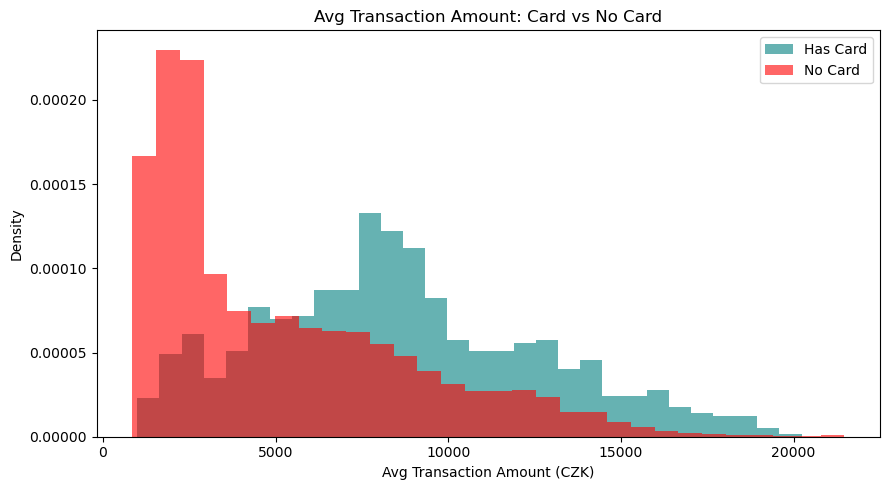

In [53]:
# Chart 1: Avg transaction amount — card vs no card
plt.figure(figsize=(9, 5))
for g, lbl, c in [(1, 'Has Card', 'TEAL'), (0, 'No Card', 'RED')]:
    sub = acc_cli2[acc_cli2['has_card'] == g]['avg_txn'].dropna()
    plt.hist(sub, bins=30, alpha=0.6, color=c, label=lbl, density=True)
plt.title('Avg Transaction Amount: Card vs No Card')
plt.xlabel('Avg Transaction Amount (CZK)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

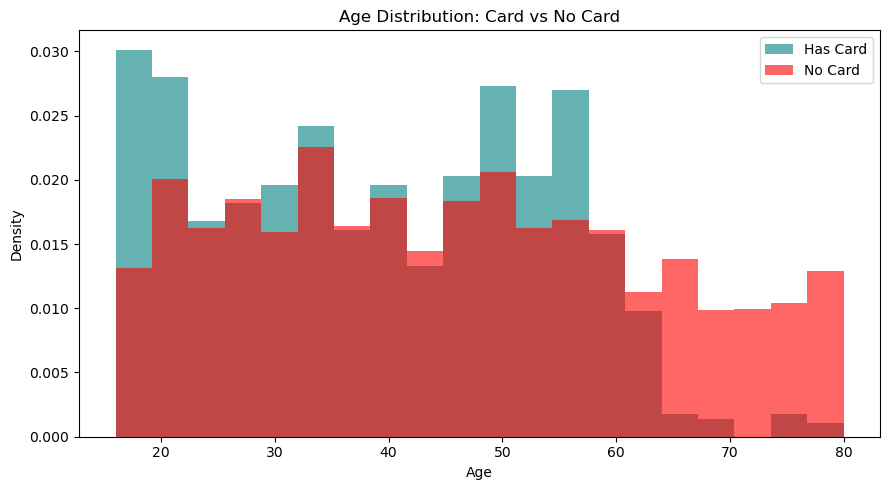

In [54]:
# Chart 2: Age — card vs no card
plt.figure(figsize=(9, 5))
for g, lbl, c in [(1, 'Has Card', 'TEAL'), (0, 'No Card', 'RED')]:
    sub = acc_cli2[acc_cli2['has_card'] == g]['age'].dropna()
    plt.hist(sub, bins=20, alpha=0.6, color=c, label=lbl, density=True)
plt.title('Age Distribution: Card vs No Card')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

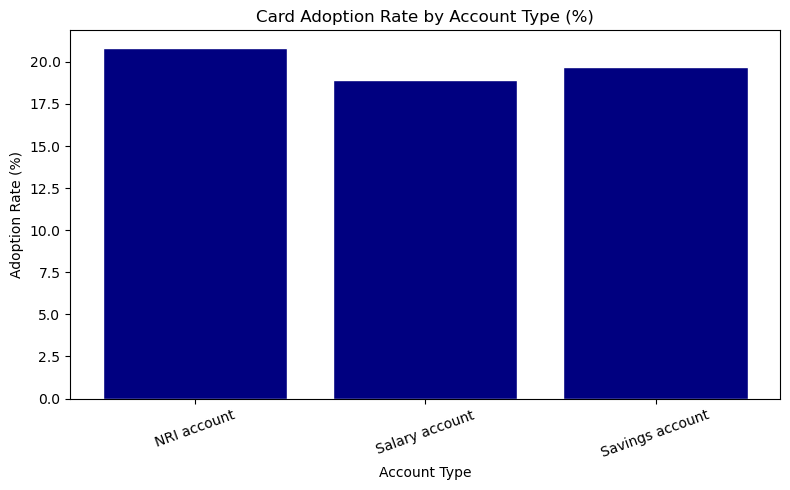

In [55]:
# Chart 3: Card adoption rate by account type
plt.figure(figsize=(8, 5))
car_by_type = acc_cli2.groupby('Account_type')['has_card'].mean() * 100
plt.bar(car_by_type.index, car_by_type.values, color='NAVY', edgecolor='white')
plt.title('Card Adoption Rate by Account Type (%)')
plt.xlabel('Account Type')
plt.ylabel('Adoption Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## DORMANT ACCOUNTS

In [56]:
active_ids   = set(transaction['account_id'].unique())
all_ids      = set(account['account_id'].unique())
dormant_ids  = all_ids - active_ids
dormant_rate = len(dormant_ids) / len(all_ids) * 100
print(f"Dormant Account Rate (KPI): {dormant_rate:.1f}%")
print(f"Active: {len(active_ids):,}  |  Dormant: {len(dormant_ids):,}")
 
account['is_dormant'] = account['account_id'].isin(dormant_ids).astype(int)
dormant_df = account.merge(
    district[['district_id', 'name', 'region', 'avg_salary']], on='district_id', how='left')

Dormant Account Rate (KPI): 0.0%
Active: 4,500  |  Dormant: 0


# DECLINING TRANSACTION TYPES

In [57]:
txn_trend = (transaction.groupby(['year', 'type_lbl'])['amount']
             .sum().reset_index())

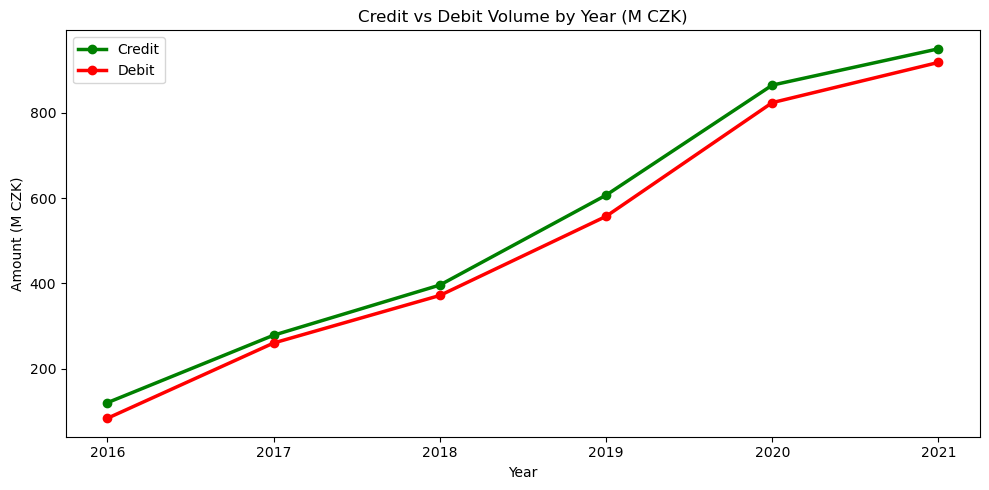

In [73]:
# Chart 1: Credit vs debit by year
plt.figure(figsize=(10, 5))
for t, c in [('Credit', 'GREEN'), ('Debit', 'RED')]:
    sub = txn_trend[txn_trend['type_lbl'] == t]
    plt.plot(sub['year'], sub['amount'] / 1e6,
             label=t, color=c, marker='o', linewidth=2.5)
plt.title('Credit vs Debit Volume by Year (M CZK)')
plt.xlabel('Year')
plt.ylabel('Amount (M CZK)')
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
txn_trend['prev_amount'] = txn_trend.groupby('type_lbl')['amount'].shift(1)

txn_trend['YoY_Growth_%'] = (
    (txn_trend['amount'] - txn_trend['prev_amount'])
    / txn_trend['prev_amount'] * 100
).round(2)

txn_trend

,year,type_lbl,amount,prev_amount,YoY_Growth_%
0,2016,Credit,120442617,NaN,NaN
1,2016,Debit,83867370,NaN,NaN
2,2017,Credit,278536213,120442617.0,131.26
3,2017,Debit,260260433,83867370.0,210.32
4,2018,Credit,396068569,278536213.0,42.20
5,2018,Debit,371670628,260260433.0,42.81
6,2019,Credit,606772930,396068569.0,53.20
7,2019,Debit,557091319,371670628.0,49.89
8,2020,Credit,864695012,606772930.0,42.51
9,2020,Debit,823652878,557091319.0,47.85


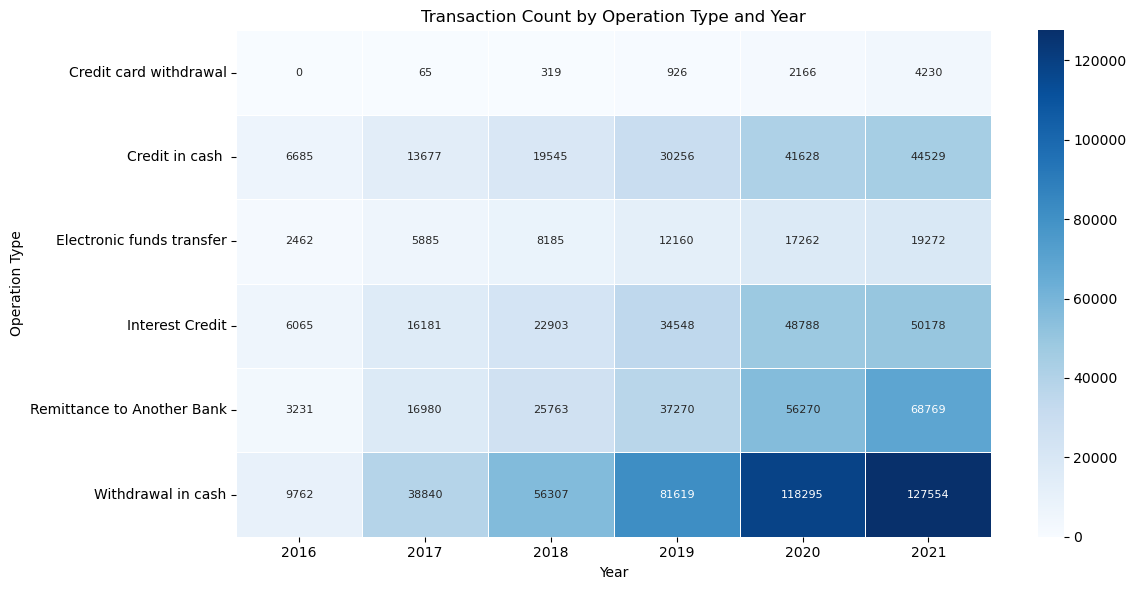

In [60]:
# Chart 2: Operation type heatmap
op_trend  = (transaction.groupby(['year', 'operation'])['trans_id']
             .count().reset_index(name='count'))
op_pivot  = op_trend.pivot(index='operation', columns='year', values='count').fillna(0)
 
plt.figure(figsize=(12, 6))
sns.heatmap(op_pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Transaction Count by Operation Type and Year')
plt.xlabel('Year')
plt.ylabel('Operation Type')
plt.tight_layout()
plt.show()

# LOAN DEFAULT PREDICTION (Logistic Regression)

In [61]:
from sklearn.linear_model    import LogisticRegression, LinearRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (accuracy_score, roc_auc_score,
                                     classification_report,
                                     confusion_matrix, ConfusionMatrixDisplay,
                                     RocCurveDisplay, mean_absolute_error, r2_score)
 
print("\n--- C1. LOAN DEFAULT PREDICTION ---")
 
# Build features
txn_feat = transaction.groupby('account_id').agg(
    txn_count      = ('trans_id', 'count'),
    avg_txn_amount = ('amount',   'mean'),
    avg_balance    = ('balance',  'mean')).reset_index()
 
card_flag = (disp.merge(card[['disp_id']], on='disp_id', how='inner')
             .groupby('account_id').size().reset_index(name='card_count'))
card_flag['has_card'] = 1
 
ml_base = (loan_cli
           .merge(txn_feat,  on='account_id', how='left')
           .merge(card_flag[['account_id', 'has_card']], on='account_id', how='left'))
ml_base['has_card']  = ml_base['has_card'].fillna(0)
ml_base['is_female'] = (ml_base['gender'] == 'F').astype(int) \
                        if 'gender' in ml_base.columns else 0
for c in ['age', 'avg_salary', 'avg_txn_amount', 'avg_balance', 'txn_count']:
    if c in ml_base.columns:
        ml_base[c] = ml_base[c].fillna(ml_base[c].median())
 
C1 = ml_base[ml_base['status'].isin(['A', 'D'])].copy()
C1 = C1.dropna(subset=['amount', 'duration', 'payments', 'is_default'])
 
FEAT_C1 = [f for f in ['amount', 'duration', 'payments', 'age', 'is_female',
                         'avg_salary', 'has_card', 'avg_txn_amount',
                         'avg_balance', 'txn_count'] if f in C1.columns]
X1 = C1[FEAT_C1]
y1 = C1['is_default']
 
X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1)
sc1      = StandardScaler()
X1_tr_s  = sc1.fit_transform(X1_tr)
X1_te_s  = sc1.transform(X1_te)
 
m1       = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
m1.fit(X1_tr_s, y1_tr)
y1_pred  = m1.predict(X1_te_s)
y1_prob  = m1.predict_proba(X1_te_s)[:, 1]
acc1     = accuracy_score(y1_te, y1_pred)
auc1     = roc_auc_score(y1_te, y1_prob)
 
print(f"Accuracy : {acc1 * 100:.2f}%")
print(f"AUC-ROC  : {auc1:.4f}")
print(classification_report(y1_te, y1_pred, target_names=['No Default', 'Default']))


--- C1. LOAN DEFAULT PREDICTION ---
Accuracy : 92.00%
AUC-ROC  : 0.9783
              precision    recall  f1-score   support

  No Default       0.97      0.93      0.95        41
     Default       0.73      0.89      0.80         9

    accuracy                           0.92        50
   macro avg       0.85      0.91      0.88        50
weighted avg       0.93      0.92      0.92        50



<Figure size 600x500 with 0 Axes>

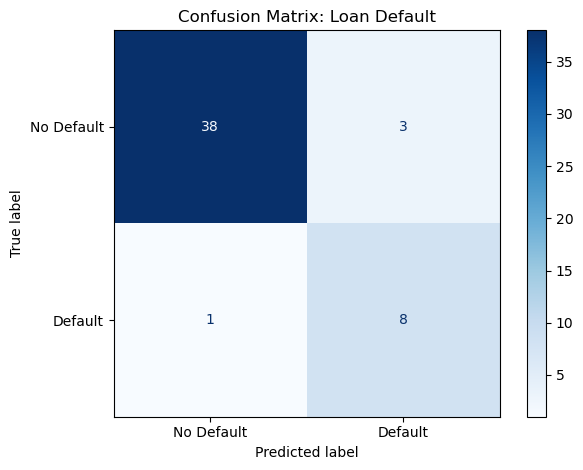

In [75]:
# Chart 1: Confusion matrix
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y1_te, y1_pred),
    display_labels=['No Default', 'Default']).plot(cmap='Blues')
plt.title('Confusion Matrix: Loan Default')
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

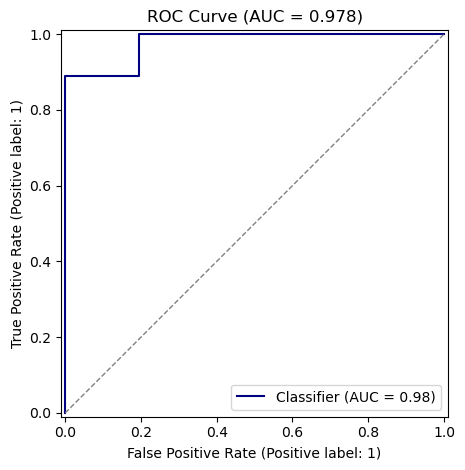

In [74]:
# Chart 2: ROC curve
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(y1_te, y1_prob, color='NAVY')
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
plt.title(f'ROC Curve (AUC = {auc1:.3f})')
plt.tight_layout()
plt.show()

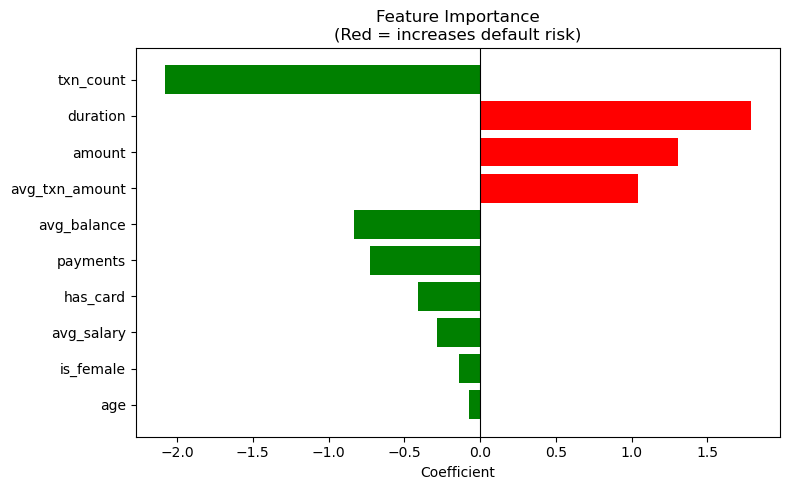

In [76]:
# Chart 3: Feature importance
plt.figure(figsize=(8, 5))
coef_df = pd.DataFrame({'Feature': FEAT_C1, 'Coef': m1.coef_[0]})
coef_df = coef_df.sort_values('Coef', key=abs)
bar_colors = ['RED' if c > 0 else 'GREEN' for c in coef_df['Coef']]
plt.barh(coef_df['Feature'], coef_df['Coef'], color=bar_colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Importance\n(Red = increases default risk)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()